# Assignment 05: Raster Data and Environmental Covariates

## BIO597 Spatial Analysis of Biodiversity

This assignment asks you to repeat and extend the raster workflow from Lab 05. You will clip WorldClim rasters to Maine, extract environmental values for selected amphibian occurrences, compare species, and document your predictor choices.

## Deliverable

Submit a completed notebook containing code, raster maps, an occurrence-environment table, and species summaries.

## Learning goals

By the end of this assignment, you should be able to:

* inspect raster metadata and identify alignment problems
* clip global rasters to a study-area polygon
* extract raster values at point locations
* recognize and retain NoData values
* select predictors based on ecological meaning rather than availability alone
* document a reproducible environmental-data workflow

## Data

Use:

* `Amphibians_ME/Amphibians_ME.csv` for occurrence records
* `/home/jovyan/shared-readwrite/bioclim` for WorldClim 2.1 bioclimatic rasters
* `../labs/ME_ShapeFiles/Maine_State_Boundary.shp` for the clipping boundary

The WorldClim files represent 1970–2000 climate normals at 2.5 arc-minute resolution. Variable definitions are available from the [WorldClim bioclimatic variable page](https://www.worldclim.org/data/bioclim.html).

## 1. Import packages

Import `pandas`, `geopandas`, `rioxarray`, and `xarray` using the same abbreviations as Lab 05.
Also import `Path` from the `pathlib` module as we did previously

In [2]:
pip install rioxarray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.1/39.1 MB 120.2 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 121.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [rioxarray]/4 [xarray]o]
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import the four packages here.
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
import xarray as xr

## 2. Load and combine the Maine boundary

Read `Maine_State_Boundary.shp`. Inspect its CRS and shape, then use `dissolve()` to combine the polygons.

In [5]:
boundary_path = "../labs/ME_ShapeFiles/Maine_State_Boundary.shp"

maine_boundary = gpd.read_file(boundary_path)

print(maine_boundary.shape)
print(maine_boundary.crs)

maine_boundary = maine_boundary.dissolve()

maine_boundary
# Read the boundary.
# Print its CRS and shape.
# Dissolve it to one row.

(6204, 10)
EPSG:4326


,geometry,OBJECTID,LAND,GlobalID,created_us,created_da,last_edite,last_edi_1,Shape__Are,Shape__Len
0,"MULTIPOLYGON (((-70.60685 42.97751, -70.60673 ...",1,y,25ab82ef-ffa7-4098-a01a-01a5c1dfc6fc,Emily.Pettit@maine.gov_maine,2021-08-02,Emily.Pettit@maine.gov_maine,2021-08-02,8.302555e+10,5.736060e+06


## 3. Open annual mean temperature

Open `wc2.1_2.5m_bio_1.tif` with `masked=True`. Store the result as `bio1`.

In [13]:
from pathlib import Path
bioclim_path = Path("/home/jovyan/shared/bioclim")
bio1_path = bioclim_path / "wc2.1_2.5m_bio_1.tif"

bio1 = rxr.open_rasterio(
    bio1_path,
    masked=True,
)

bio1

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.166666030884
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -54.759166717529
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

## 4. Inspect annual mean temperature metadata

Report:

* dimensions and shape
* data type
* CRS
* resolution
* bounds
* NoData value

Add a brief comment beside each output explaining what it describes.

In [18]:
# Print the requested raster metadata here.
print("Dimensions:", bio1.dims) #it says what type of information it has
print("Shape:", bio1.shape) #it says hoow many data points per item
print("Data type:", bio1.dtype) #what type of fomrat the data is in
print("CRS:", bio1.rio.crs) #which coordiante reference system is in use
print("Resolution:", bio1.rio.resolution()) #the resolution in degrees
print("Bounds:", bio1.rio.bounds()) #the geographical extent. 
print("NoData:", bio1.rio.nodata)

Dimensions: ('band', 'y', 'x')
Shape: (1, 4320, 8640)
Data type: float32
CRS: EPSG:4326
Resolution: (0.041666666666666664, -0.041666666666666664)
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
NoData: nan


## 5. Clip BIO1 to Maine

Use `rio.clip()` with the dissolved boundary. Set `drop=True` and `from_disk=True`, then remove the one-band dimension with `squeeze()`.

In [19]:
bio1_maine = bio1.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio1_maine = bio1_maine.squeeze()

## 6. Compare the global and clipped rasters

Display the shape, bounds, CRS, and resolution of both. State which properties changed and which remained the same.

In [20]:
# Compare global and clipped metadata here.
print("Global shape:", bio1.shape)
print("Maine shape:", bio1_maine.shape)
print("Maine bounds:", bio1_maine.rio.bounds())
print("Maine resolution:", bio1_maine.rio.resolution())


Global shape: (1, 4320, 8640)
Maine shape: (109, 101)
Maine bounds: (-71.125, 42.95833333333333, -66.91666666666667, 47.5)
Maine resolution: (0.04166666666666671, -0.041666666666666664)


**Your comparison:** shape and bounds changed, while resolution stayed the same


## 7. Plot annual mean temperature for Maine

Use the DataArray's `.plot()` method and choose an appropriate colormap.

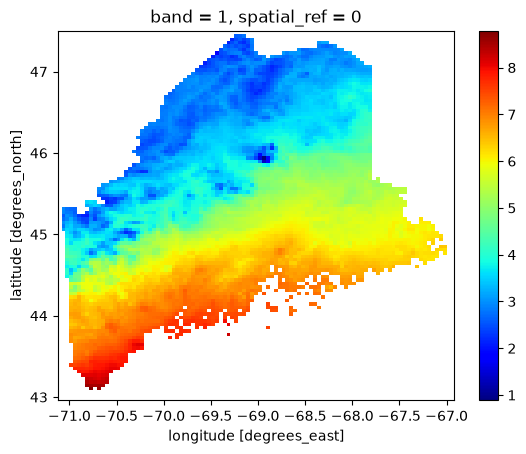

In [21]:
# Plot bio1_maine here.
bio1_maine.plot(cmap="jet")

## 8. Choose three additional bioclimatic variables

Choose three variables from BIO2 through BIO19. Include at least one temperature variable and at least one precipitation variable.

Do not choose variables only because they are available. Give a short biological reason for each choice.

**Variable 1 and justification:** Bio5. warmest temperature is likely the most important feature for amphibians.

**Variable 2 and justification:** Bio12. precipitation is generally important for amphibians that rely on moisture. 

**Variable 3 and justification:** bio15. precipitation seasonality could lead to dessication. 

## 9. Open the first additional raster

Build its filename, open it with `masked=True`, and inspect its CRS, shape, resolution, and bounds.

In [22]:
# Open your first additional raster.
# Inspect its metadata.

bioclim_path = Path("/home/jovyan/shared/bioclim")
bio5_path = bioclim_path / "wc2.1_2.5m_bio_5.tif"

bio5 = rxr.open_rasterio(
    bio5_path,
    masked=True,
)

bio5

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  48.459999084473
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -30.760000228882
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

## 10. Check alignment with BIO1

Compare CRS, shape, resolution, and bounds. Each comparison should return `True` before you treat the rasters as an aligned stack.

In [23]:
# Compare the first additional raster with bio1.

print("Same CRS:", bio1.rio.crs == bio5.rio.crs)
print("Same shape:", bio1.shape == bio5.shape)
print("Same resolution:", bio1.rio.resolution() == bio5.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio5.rio.bounds())

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


## 11. Clip and map the first additional raster

Use the same clipping settings as BIO1. Plot the Maine result with an appropriate colormap.

In [24]:
# Clip, squeeze, and plot the first additional raster.
bio5_maine = bio5.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio5_maine = bio5_maine.squeeze()

## 12. Repeat for the second additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it. Keep each part of the workflow visible in your code.

In [25]:
# Complete the workflow for the second additional raster.

# Open your first additional raster.
# Inspect its metadata.

bioclim_path = Path("/home/jovyan/shared/bioclim")
bio12_path = bioclim_path / "wc2.1_2.5m_bio_12.tif"

bio12 = rxr.open_rasterio(
    bio12_path,
    masked=True,
)

bio12

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  11246
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

In [30]:
# Compare the first additional raster with bio1.

print("Same CRS:", bio1.rio.crs == bio12.rio.crs)
print("Same shape:", bio1.shape == bio12.shape)
print("Same resolution:", bio1.rio.resolution() == bio12.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio12.rio.bounds())

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


In [31]:
# Clip, squeeze, and plot the first additional raster.
bio12_maine = bio12.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio12_maine = bio12_maine.squeeze()

## 13. Repeat for the third additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it.

In [28]:
# Complete the workflow for the third additional raster.
# Complete the workflow for the second additional raster.

# Open your first additional raster.
# Inspect its metadata.

bioclim_path = Path("/home/jovyan/shared/bioclim")
bio15_path = bioclim_path / "wc2.1_2.5m_bio_15.tif"

bio15 = rxr.open_rasterio(
    bio15_path,
    masked=True,
)

bio15


<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  230.69151306152
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

In [32]:
# Compare the first additional raster with bio1.

print("Same CRS:", bio1.rio.crs == bio15.rio.crs)
print("Same shape:", bio1.shape == bio15.shape)
print("Same resolution:", bio1.rio.resolution() == bio15.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio15.rio.bounds())

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


In [33]:
# Clip, squeeze, and plot the first additional raster.
bio15_maine = bio15.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio15_maine = bio15_maine.squeeze()

## 14. Load the amphibian records

Read the tab-delimited occurrence file. Keep `gbifID`, `species`, longitude, latitude, and year.

In [60]:
amphibians_gdf = gpd.read_file(
    "../assignments/Amphibians_ME/Amphibians_ME.csv",
    x_possible_names="decimalLongitude",
    y_possible_names="decimalLatitude",
).set_crs("EPSG:4326")

## Remove rows without species labels
amphibians_gdf = amphibians_gdf[amphibians_gdf["species"] != ""]
amphibians_gdf.shape

keep = ['gbifID', 'species', 'decimalLongitude', 'decimalLatitude', 'year','geometry']

amphibians_gdf = amphibians_gdf[keep]
amphibians_gdf.head()
# Keep the five requested columns.

,gbifID,species,decimalLongitude,decimalLatitude,year,geometry
0,6520738729,Lithobates catesbeianus,-68.660278,44.902551,2026,POINT (-68.66028 44.90255)
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026,POINT (-69.64901 44.73571)
2,6520729466,Boreorana sylvatica,-69.889241,44.798325,2026,POINT (-69.88924 44.79832)
3,6520721493,Lithobates palustris,-68.636788,44.860466,2022,POINT (-68.63679 44.86047)
4,6520718655,Lithobates pipiens,-68.788851,44.990948,2026,POINT (-68.78885 44.99095)


## 15. Prepare the occurrence coordinates

Convert longitude and latitude to numeric columns. Remove records missing species or coordinates.

In [61]:
# Convert both coordinate columns with pd.to_numeric().
# Drop rows missing species, longitude, or latitude.
amphibians_gdf.decimalLatitude = pd.to_numeric(amphibians_gdf.decimalLatitude)
amphibians_gdf.decimalLongitude = pd.to_numeric(amphibians_gdf.decimalLongitude)


## 16. Choose three amphibian species

Inspect the species counts, then choose three species with enough records for comparison.

In [62]:
amphibians["species"].value_counts().head(20)

species
Aquarana clamitans            2966
Plethodon cinereus            2864
Pseudacris crucifer           2801
Anaxyrus americanus           2800
Boreorana sylvatica           2794
Ambystoma maculatum           2511
Lithobates catesbeianus       2302
Lithobates palustris          1626
Dryophytes versicolor         1411
Notophthalmus viridescens     1029
Lithobates pipiens             561
Eurycea bislineata             516
Hemidactylium scutatum         334
Ambystoma laterale             322
Desmognathus fuscus            215
Aquarana septentrionalis       198
Gyrinophilus porphyriticus     134
Aquarana catesbeiana            81
Rana arvalis                    54
Ambystoma jeffersonianum        37
Name: count, dtype: int64

**Species 1:** Aquarana clamitans 

**Species 2:** Plethodon cinereus

**Species 3:** Pseudacris crucifer

In [63]:
selected_species = [
    "Aquarana clamitans",
    "Plethodon cinereus",
    "Pseudacris crucifer",
]

amphibians_gdf = amphibians_gdf[
    amphibians_gdf["species"].isin(selected_species)
].copy()

amphibians_gdf.head()
# Filter the occurrence table with .isin(selected_species).

,gbifID,species,decimalLongitude,decimalLatitude,year,geometry
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026,POINT (-69.64901 44.73571)
6,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026,POINT (-68.70405 44.78842)
15,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026,POINT (-70.85036 44.27281)
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026,POINT (-70.45687 43.99431)
17,6520610648,Aquarana clamitans,-70.399019,43.934882,2026,POINT (-70.39902 43.93488)


## 17. Create an occurrence GeoDataFrame

Use longitude and latitude to create point geometry. Assign `EPSG:4326`.

In [ ]:
# Create selected_amphibians_gdf here.

## 18. Confirm coordinate systems

Print the occurrence CRS and raster CRS. Explain what must be true before extracting raster values.

In [74]:
# Print both coordinate systems.
print(amphibians_gdf.crs)


EPSG:4326


**Your explanation:** they have the same CRS

## 19. Prepare coordinates for extraction

Create `xarray.DataArray` objects called `point_x` and `point_y`. Use one dimension named `record`.

In [66]:
# Create point_x from point longitude.
# Create point_y from point latitude.
point_x = xr.DataArray(
    amphibians_gdf.geometry.x.to_numpy(),
    dims="record",
)

point_y = xr.DataArray(
    amphibians_gdf.geometry.y.to_numpy(),
    dims="record",
)

## 20. Extract annual mean temperature

Use `.sel()` with `x`, `y`, and `method="nearest"`. Add the extracted values to a clearly named column in the occurrence GeoDataFrame.

In [67]:
bio1_values = bio1_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

amphibians_gdf["bio1_mean_temp_c"] = bio1_values
amphibians_gdf.head()


# Add the values to selected_amphibians_gdf.

,gbifID,species,decimalLongitude,decimalLatitude,year,geometry,bio1_mean_temp_c
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026,POINT (-69.64901 44.73571),6.332833
6,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026,POINT (-68.70405 44.78842),6.634333
15,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026,POINT (-70.85036 44.27281),6.033667
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026,POINT (-70.45687 43.99431),6.875500
17,6520610648,Aquarana clamitans,-70.399019,43.934882,2026,POINT (-70.39902 43.93488),6.888000


## 21. Inspect missing extracted values

Count missing BIO1 values. Explain why coastal occurrences may be assigned NoData even when the coordinates are valid.

In [68]:
# Count missing extracted BIO1 values.
amphibians_gdf["bio1_mean_temp_c"].isna().value_counts()

bio1_mean_temp_c
False    7612
True     1019
Name: count, dtype: int64

**Your explanation:** many sites have no values, perhaps because they are not captured in an island grid

## 22. Extract the three additional variables

Use the same `point_x` and `point_y` arrays. Add one clearly named column for each variable. The column names should include units where practical.

In [80]:
# Extract values from the first additional clipped raster.
# Add the values to selected_amphibians_gdf.
bio5_values = bio5_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

amphibians_gdf["bio5_max_temp_c"] = bio5_values
amphibians_gdf.head()


,gbifID,species,decimalLongitude,decimalLatitude,year,geometry,bio1_mean_temp_c,bio5_mean_temp_c,bio12_mean_temp_c,bio15_mean_temp_c,bio5_max_temp_c
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026,POINT (-69.64901 44.73571),6.332833,26.612000,1051.0,12.902308,26.612000
6,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026,POINT (-68.70405 44.78842),6.634333,26.588001,1091.0,9.557447,26.588001
15,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026,POINT (-70.85036 44.27281),6.033667,26.004000,1126.0,11.435465,26.004000
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026,POINT (-70.45687 43.99431),6.875500,26.136000,1162.0,11.347319,26.136000
17,6520610648,Aquarana clamitans,-70.399019,43.934882,2026,POINT (-70.39902 43.93488),6.888000,26.007999,1173.0,11.627544,26.007999


In [81]:
# Extract values from the second additional clipped raster.
# Add the values to selected_amphibians_gdf.
bio12_values = bio12_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

amphibians_gdf["bio12_mean_precip_c"] = bio12_values
amphibians_gdf.head()


,gbifID,species,decimalLongitude,decimalLatitude,year,geometry,bio1_mean_temp_c,bio5_mean_temp_c,bio12_mean_temp_c,bio15_mean_temp_c,bio5_max_temp_c,bio12_mean_precip_c
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026,POINT (-69.64901 44.73571),6.332833,26.612000,1051.0,12.902308,26.612000,1051.0
6,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026,POINT (-68.70405 44.78842),6.634333,26.588001,1091.0,9.557447,26.588001,1091.0
15,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026,POINT (-70.85036 44.27281),6.033667,26.004000,1126.0,11.435465,26.004000,1126.0
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026,POINT (-70.45687 43.99431),6.875500,26.136000,1162.0,11.347319,26.136000,1162.0
17,6520610648,Aquarana clamitans,-70.399019,43.934882,2026,POINT (-70.39902 43.93488),6.888000,26.007999,1173.0,11.627544,26.007999,1173.0


In [82]:
# Extract values from the third additional clipped raster.
# Add the values to selected_amphibians_gdf.
bio15_values = bio15_maine.sel(
    x=point_x,
    y=point_y,
    method="nearest",
)

amphibians_gdf["bio15_precip_season"] = bio15_values
amphibians_gdf.head()


,gbifID,species,decimalLongitude,decimalLatitude,year,geometry,bio1_mean_temp_c,bio5_mean_temp_c,bio12_mean_temp_c,bio15_mean_temp_c,bio5_max_temp_c,bio12_mean_precip_c,bio15_precip_season
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026,POINT (-69.64901 44.73571),6.332833,26.612000,1051.0,12.902308,26.612000,1051.0,12.902308
6,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026,POINT (-68.70405 44.78842),6.634333,26.588001,1091.0,9.557447,26.588001,1091.0,9.557447
15,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026,POINT (-70.85036 44.27281),6.033667,26.004000,1126.0,11.435465,26.004000,1126.0,11.435465
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026,POINT (-70.45687 43.99431),6.875500,26.136000,1162.0,11.347319,26.136000,1162.0,11.347319
17,6520610648,Aquarana clamitans,-70.399019,43.934882,2026,POINT (-70.39902 43.93488),6.888000,26.007999,1173.0,11.627544,26.007999,1173.0,11.627544


## 23. Create the occurrence-environment table

Remove the geometry column and display the first five rows. Confirm that the table contains species, coordinates, year, and four environmental variables.

In [79]:
# Create and display occurrence_environment.
occurrence_environment = amphibians_gdf.drop(columns="geometry")

occurrence_environment.head()

,gbifID,species,decimalLongitude,decimalLatitude,year,bio1_mean_temp_c,bio5_mean_temp_c,bio12_mean_temp_c,bio15_mean_temp_c
1,6520735611,Aquarana clamitans,-69.649014,44.735713,2026,6.332833,26.612000,1051.0,12.902308
6,6520702458,Pseudacris crucifer,-68.704049,44.788417,2026,6.634333,26.588001,1091.0,9.557447
15,6520620737,Pseudacris crucifer,-70.850360,44.272807,2026,6.033667,26.004000,1126.0,11.435465
16,6520617346,Plethodon cinereus,-70.456871,43.994310,2026,6.875500,26.136000,1162.0,11.347319
17,6520610648,Aquarana clamitans,-70.399019,43.934882,2026,6.888000,26.007999,1173.0,11.627544


## 24. Summarize environmental values by species

For each selected species, calculate:

* number of records
* mean of each environmental variable
* standard deviation of each environmental variable

In [89]:
# Calculate species-level summaries here.

predictor_columns = [
    "bio1_mean_temp_c",
    "bio5_mean_temp_c",
    "bio12_mean_temp_c",
    "bio15_mean_temp_c",
]

for species, samples in occurrence_environment.groupby("species"):
    print(species, len(samples), "\n", samples[predictor_columns].mean())
for species, samples in occurrence_environment.groupby("species"):
    print(species, len(samples), "\n", samples[predictor_columns].std())


Aquarana clamitans 2966 
 bio1_mean_temp_c        6.381768
bio5_mean_temp_c       25.551930
bio12_mean_temp_c    1150.621278
bio15_mean_temp_c      13.811705
dtype: float64
Plethodon cinereus 2864 
 bio1_mean_temp_c        6.868341
bio5_mean_temp_c       25.553639
bio12_mean_temp_c    1178.368842
bio15_mean_temp_c      14.067693
dtype: float64
Pseudacris crucifer 2801 
 bio1_mean_temp_c        6.551031
bio5_mean_temp_c       25.853299
bio12_mean_temp_c    1138.147793
bio15_mean_temp_c      13.172701
dtype: float64
Aquarana clamitans 2966 
 bio1_mean_temp_c      1.321338
bio5_mean_temp_c      0.987250
bio12_mean_temp_c    99.083724
bio15_mean_temp_c     2.799461
dtype: float64
Plethodon cinereus 2864 
 bio1_mean_temp_c       1.040450
bio5_mean_temp_c       1.035644
bio12_mean_temp_c    103.158168
bio15_mean_temp_c      3.024617
dtype: float64
Pseudacris crucifer 2801 
 bio1_mean_temp_c      1.238711
bio5_mean_temp_c      0.793951
bio12_mean_temp_c    81.641549
bio15_mean_temp_c     2.47

## 25. Check relationships among predictors

Create a correlation table for your four environmental variables. Identify any pair with a strong relationship.

In [87]:
# Select the four predictor columns and calculate .corr().
occurrence_environment[predictor_columns].corr().round(2)

,bio1_mean_temp_c,bio5_mean_temp_c,bio12_mean_temp_c,bio15_mean_temp_c
bio1_mean_temp_c,1.00,0.39,0.41,-0.16
bio5_mean_temp_c,0.39,1.00,-0.24,-0.66
bio12_mean_temp_c,0.41,-0.24,1.00,0.57
bio15_mean_temp_c,-0.16,-0.66,0.57,1.00


**Interpretation:** Which predictors contain similar information? Would you retain all of them in the same model? Explain your reasoning. they all have weak correlations. i would retain them

## 27. Save your occurrence-environment table

Save it as `Assignment05_environmental_values.csv` beside this notebook. Do not include the DataFrame index.

In [88]:
# Save occurrence_environment with .to_csv().
occurrence_environment.to_csv(
    "Assignment05_environmental_values.csv",
    index=False,
)

## Final reflection

Answer each question in two or three sentences.

1. How do raster resolution and occurrence-coordinate uncertainty interact? since the raster is a defined grid, the vector uncertianty will determin if that grid is considered or not.  
2. What environmental variation is lost when all occurrences in one raster cell receive the same value? heterogeneity is lost. 
3. Which predictor has the strongest biological justification for your selected species? precipitation is highly predictive. 
4. Which preprocessing choice is most important to document for reproducibility? An important chioce is the uncertainty filtering.
5. Name one additional environmental predictor you would seek for an amphibian study and explain why. I would also see coldest month because this can also restrain the range. 

## Submit your work

Run the notebook from top to bottom. Make sure all raster maps, tables, and written answers are complete. Then commit and push the completed notebook to your class GitHub repository.

```bash
git add docs/assignments/Assignment-05-RasterData.ipynb
git commit -m "Complete raster data assignment"
git push
```